<a href="https://colab.research.google.com/github/sreenathsnv/AI-ML/blob/ML-models/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AdaBoost

suppose we have the given dataset

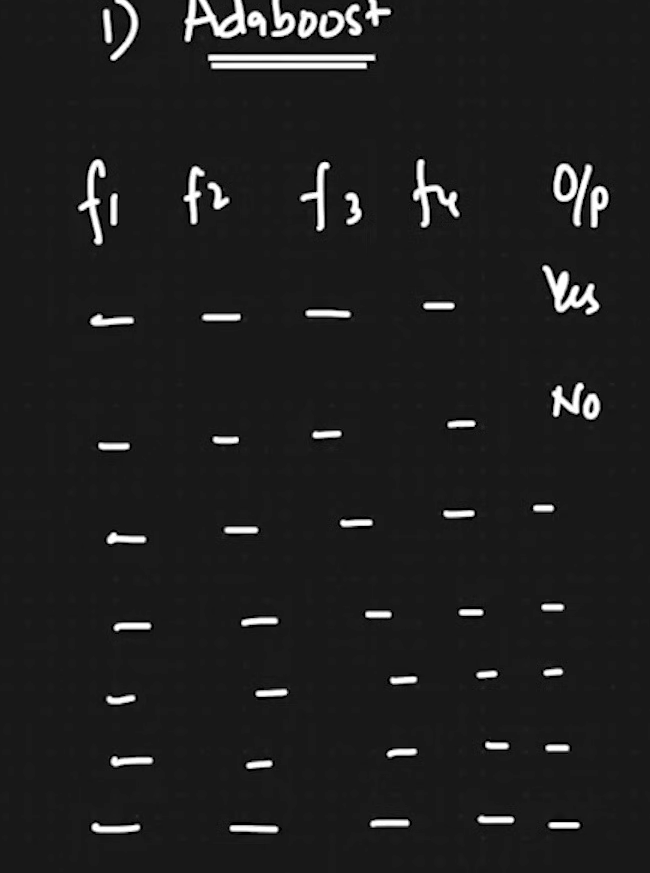

then we will add weights to all the features as below , where the number of features is 7. **The sum of all the weights should be 1**

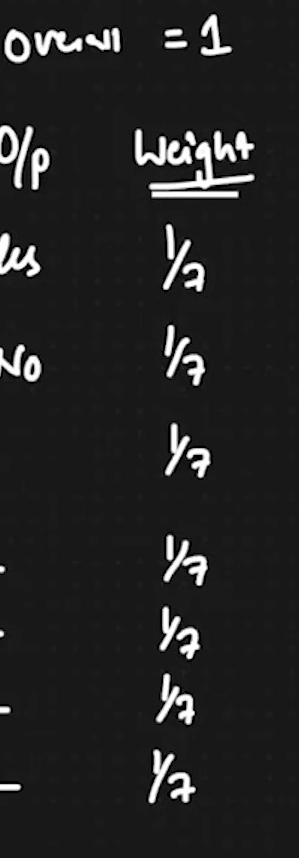

## Next step

we will finmd **information gain (IG)** for all the features and start creating decision trees wrt the IG value

Here all the decsion tree will have the max depth of 1
Each tree is known as **Stumps**

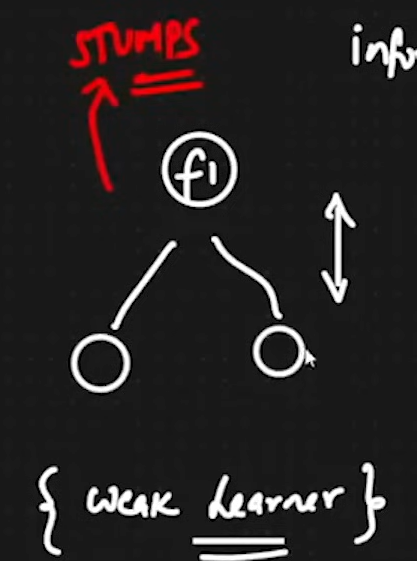

## Next step


##### 1.  After creating a the tree for f1, we need to find the Total error which is the **sum of the weights of the misclassified samples**

##### 2.  After this we need to find the perfomance of the stump,by Perf(Stump f1) =
$$
Perfomance \,\,\, , \,\,\,
\alpha_t = \frac{1}{2} \ln \left(\frac{1 - Error_{total}}{Error_{total}}\right)
$$

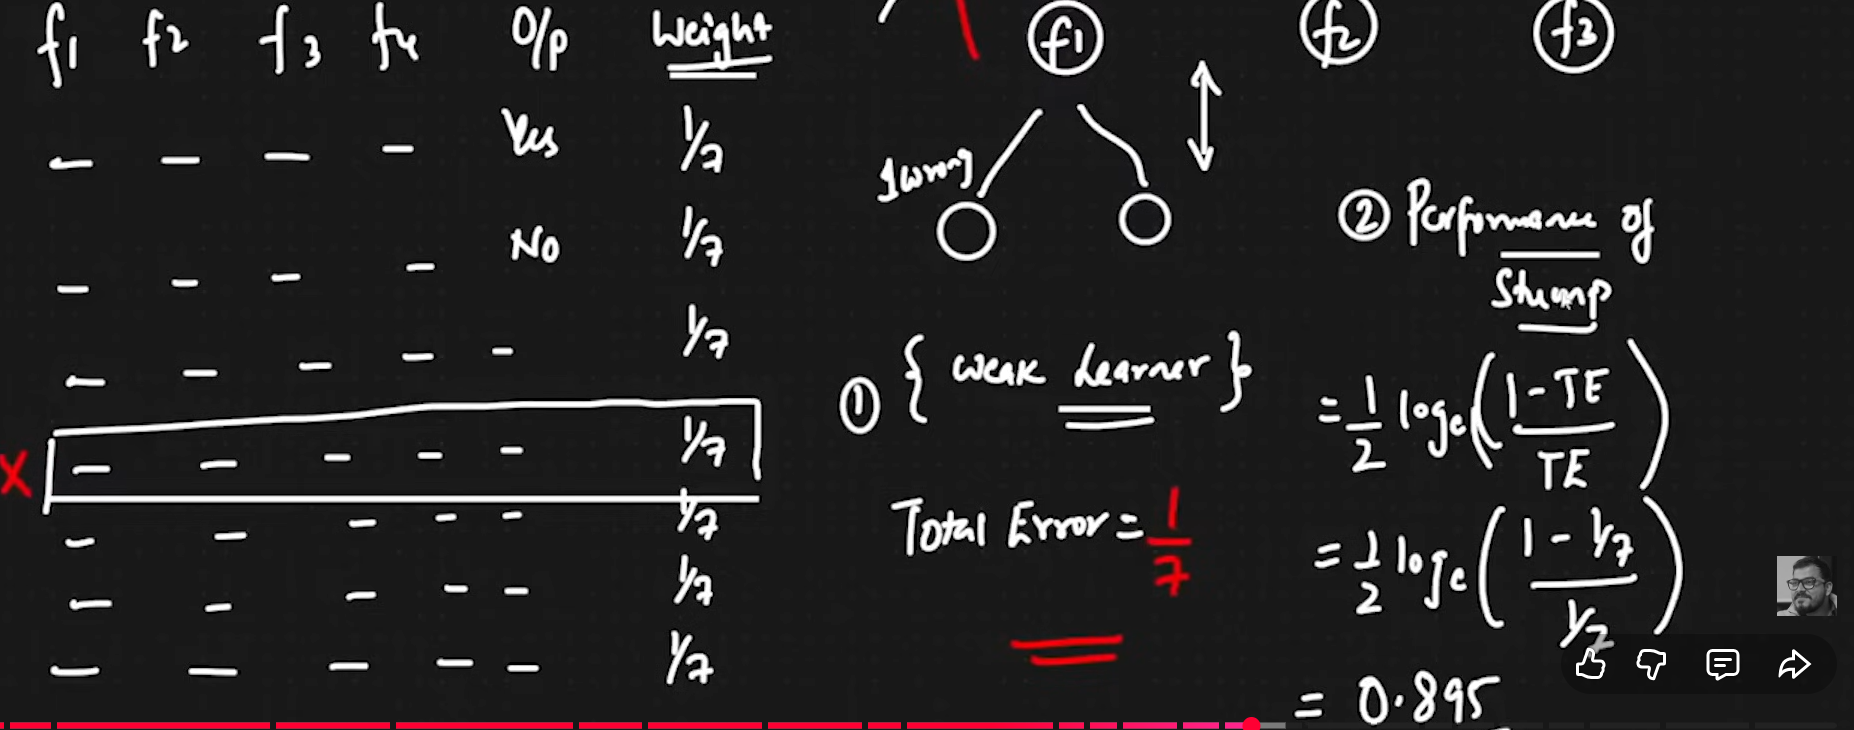

##### 3. Now calculate the new weights for all the records **other than the incorrect ones** with the below formula
## $$\text{weight} \cdot e^{-\alpha_t}$$

##### for the incorrect records,
## $$\text{weight} \cdot e^{\alpha_t}$$

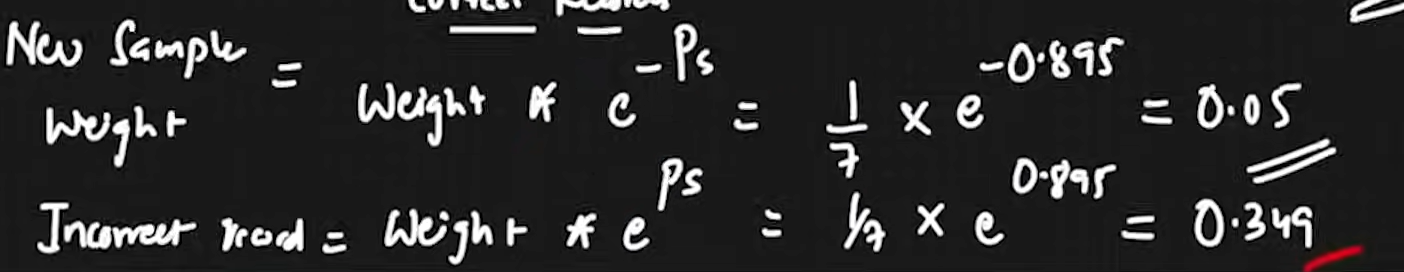

##### 4. update the table with new weights
##### 5. Find the sum of the weights for **Normalization**
##### 6. divide all the weights by the sum
##### 7. Update the weight table

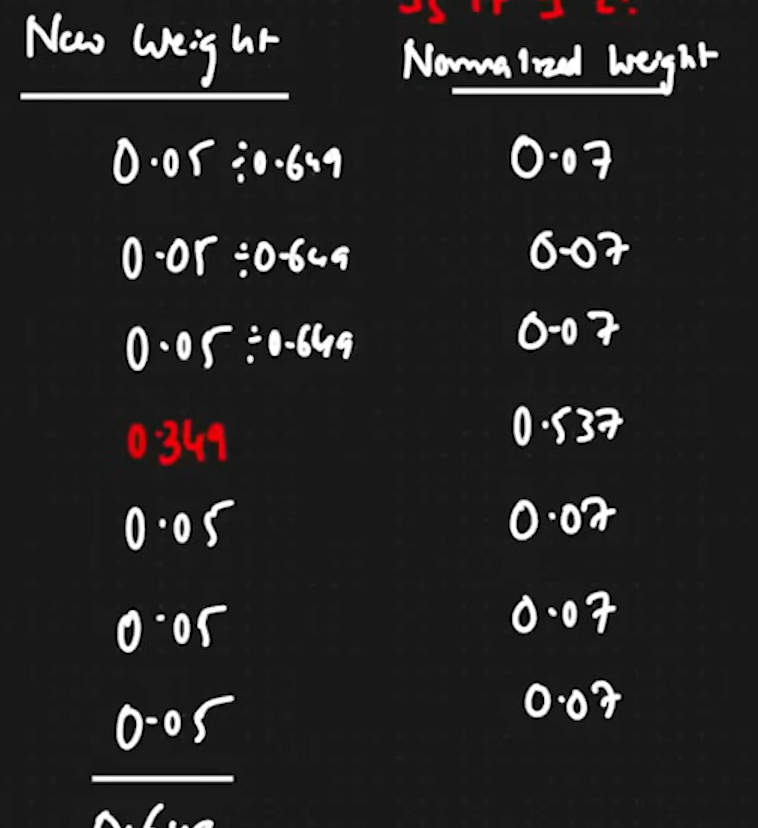

##### 8. ow create a fresh dataset to see whether or not the mistakes have decreased. To do this, we will delete the "sample weights" and "new sample weights" columns and then split our data points into buckets based on the "new sample weights.

##### To build the new dataset, the algorithm acts like a random number generator:

##### It picks a random number between 0 and 1.

##### It checks which bucket that number falls into.

##### It copies the corresponding row into the new dataset.

##### It repeats this 5 times to get a full dataset.
### Eg:
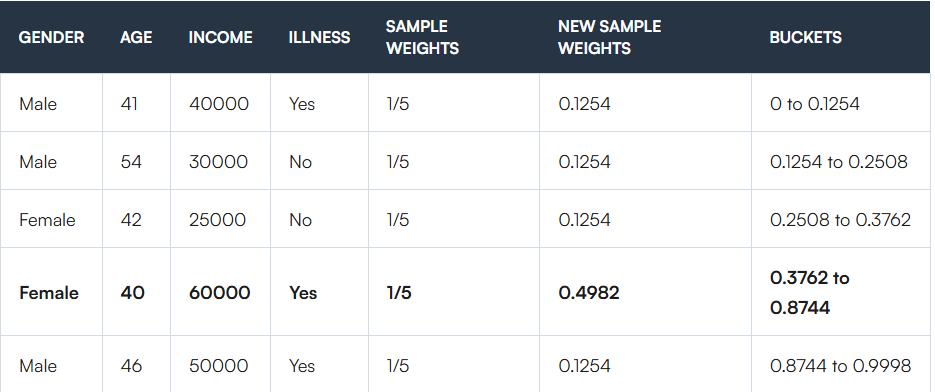

# **XGBOOST Algorithm** - Extreme Gradient Boosting



## Overview

**XGBoost (Extreme Gradient Boosting)** is a powerful boosting algorithm used for both **classification and regression problems**.

It builds a **strong predictive model** by **sequentially combining multiple weak learners**, typically **decision trees**.

Key characteristics:

- Uses **gradient boosting framework**
- Sequentially corrects previous model errors
- Highly optimized for **speed and performance**
- Considered a **black-box model** due to the complexity of many sequential trees

---

# Working of XGBoost Classifier

The process of building an XGBoost classifier consists of multiple stages.

---

# 1. Creating the Base Model

The algorithm begins with a **base model (initial prediction)**.

For classification problems, the base model predicts a **default probability of 0.5**.

### Residual Calculation

Residual represents the **difference between actual value and predicted probability**.

$$
Residual = Actual - Predicted
$$

Example:

| Actual Value | Predicted Probability | Residual |
|--------------|----------------------|----------|
| 0 | 0.5 | -0.5 |
| 1 | 0.5 | 0.5 |

### Base Model Flow

```
Input Data
    │
    ▼
Base Model
(P = 0.5 for all)
    │
    ▼
Residual Calculation
(Actual - Predicted)
```

---

# 2. Constructing Binary Decision Trees

After computing residuals, XGBoost builds **sequential binary decision trees**.

Each new tree tries to **correct the mistakes of previous trees**.

If a feature has multiple categories, it is converted into **binary splits**.

Example:

```
Credit Score

        Root
       /    \
 Good,Normal   Bad
```

### Sequential Tree Learning

```
Base Model
    │
    ▼
Tree 1 (learn residuals)
    │
    ▼
Tree 2 (correct errors)
    │
    ▼
Tree 3 (further correction)
```

---

# 3. Calculating Similarity Weight

To evaluate the quality of each node, XGBoost calculates **Similarity Weight**.

### Formula

$$
Similarity\ Weight =
\frac{(\sum Residual)^2}
{\sum (P(1-P)) + \lambda}
$$

Where:

- **Residual** = Actual − Predicted  
- **P** = predicted probability  
- **P(1 − P)** = probability variance  
- **λ (Lambda)** = regularization parameter to prevent overfitting

Higher similarity weight indicates a **better grouping of data in the node**.

---

# 4. Calculating Information Gain

To determine the **best feature split**, XGBoost computes **Information Gain**.

### Formula

$$
Information\ Gain =
Similarity_{Left}
+
Similarity_{Right}
-
Similarity_{Root}
$$

### Decision Process

```
             Root Node
            /        \
        Left Node   Right Node

Gain = Left + Right - Root
```

The feature with the **highest information gain** is selected for splitting.

---

# 5. Inferencing (Making Predictions)

After building multiple trees, the model combines them to make predictions.

---

## Step 1: Convert Probability to Log Odds

Initial probability = **0.5**

$$
Log(Odds) = log\left(\frac{P}{1-P}\right)
$$

$$
log(0.5/0.5) = 0
$$

So the **initial base score = 0**.

---

## Step 2: Pass Input Through Trees

The input sample is passed sequentially through all trees.

```
New Data
   │
   ▼
Base Score
   │
   ▼
Tree 1
   │
   ▼
Tree 2
   │
   ▼
Tree 3
```

---

## Step 3: Apply Learning Rate

Each tree's output is multiplied by a **learning rate (α)**.

$$
Output =
Base\ Value
+
(\alpha_1 \times Tree_1)
+
(\alpha_2 \times Tree_2)
+
...
+
(\alpha_n \times Tree_n)
$$

Learning rate helps **control overfitting**.

---

## Step 4: Apply Activation Function

Since this is a **classification problem**, the final output is passed through the **Sigmoid Function**.

### Sigmoid Function

$$
\sigma(x) =
\frac{1}{1 + e^{-x}}
$$

This converts the output into a **probability between 0 and 1**.

---

# Final Prediction Flow

```
Input Data
   │
   ▼
Base Model (Log Odds = 0)
   │
   ▼
Tree 1 → α × Output
   │
   ▼
Tree 2 → α × Output
   │
   ▼
Tree 3 → α × Output
   │
   ▼
Summation
   │
   ▼
Sigmoid Function
   │
   ▼
Final Probability
```

---

# Advantages of XGBoost

- Very **high predictive accuracy**
- Built-in **regularization**
- Handles **missing values automatically**
- Supports **parallel processing**
- Works well with **large datasets**

---

# Limitations

- More complex than simple models
- Hard to interpret (**black-box model**)
- Requires careful **hyperparameter tuning**

---

# Applications

- Fraud detection
- Credit risk analysis
- Customer churn prediction
- Medical diagnosis
- Recommendation systems

# XGBoost Mathematical Example

## Problem

A bank wants to **predict whether a customer loan will be approved (1) or rejected (0)** based on **Credit Score**.

Dataset:

| Customer | Credit Score | Loan Approved |
|--------|-------------|--------------|
| A | Low | 0 |
| B | Low | 0 |
| C | High | 1 |
| D | High | 1 |

Goal: Build the **first XGBoost tree mathematically**.

---

# Step 1: Base Model

For classification, the base model predicts **probability = 0.5** for all observations.

$$
P = 0.5
$$

Convert to **log odds**

$$
log\left(\frac{P}{1-P}\right)
$$

$$
log\left(\frac{0.5}{0.5}\right) = 0
$$

So the **initial prediction value = 0**.

---

# Step 2: Calculate Residuals

Residual formula:

$$
Residual = Actual - Predicted
$$

Since predicted probability = 0.5:

| Customer | Actual | Predicted | Residual |
|---------|-------|----------|----------|
| A | 0 | 0.5 | -0.5 |
| B | 0 | 0.5 | -0.5 |
| C | 1 | 0.5 | 0.5 |
| D | 1 | 0.5 | 0.5 |

---

# Step 3: Build First Decision Tree

Split using **Credit Score**

```
           Root
        Credit Score
        /         \
      Low        High
```

Low node → A, B  
High node → C, D

---

# Step 4: Calculate Similarity Weight

Formula:

$$
Similarity =
\frac{(\sum Residual)^2}{\sum(P(1-P)) + \lambda}
$$

Assume:

$$
\lambda = 1
$$

---

## Root Node

Residuals:

-0.5, -0.5, 0.5, 0.5

Sum of residuals:

$$
-0.5 -0.5 +0.5 +0.5 = 0
$$

Numerator:

$$
(0)^2 = 0
$$

Denominator:

$$
P(1-P) = 0.5(1-0.5) = 0.25
$$

Total:

$$
0.25 + 0.25 + 0.25 + 0.25 = 1
$$

Add lambda:

$$
1 + 1 = 2
$$

Similarity:

$$
0 / 2 = 0
$$

---

## Left Node (Low Credit)

Residuals:

-0.5, -0.5

Sum:

$$
-1
$$

Numerator:

$$
(-1)^2 = 1
$$

Denominator:

$$
0.25 + 0.25 = 0.5
$$

Add lambda:

$$
0.5 + 1 = 1.5
$$

Similarity:

$$
1 / 1.5 = 0.67
$$

---

## Right Node (High Credit)

Residuals:

0.5, 0.5

Sum:

$$
1
$$

Numerator:

$$
1^2 = 1
$$

Denominator:

$$
0.25 + 0.25 = 0.5
$$

Add lambda:

$$
0.5 + 1 = 1.5
$$

Similarity:

$$
1 / 1.5 = 0.67
$$

---

# Step 5: Calculate Information Gain

Formula:

$$
Gain =
Similarity_{Left}
+
Similarity_{Right}
-
Similarity_{Root}
$$

Substitute values:

$$
Gain = 0.67 + 0.67 - 0
$$

$$
Gain = 1.34
$$

Since gain is **positive**, this split is useful.

---

# Step 6: Calculate Leaf Output

Leaf weight formula:

$$
Leaf\ Weight =
\frac{\sum Residual}{\sum(P(1-P)) + \lambda}
$$

---

### Left Leaf

$$
\frac{-1}{1.5} = -0.67
$$

---

### Right Leaf

$$
\frac{1}{1.5} = 0.67
$$

---

# Step 7: Apply Learning Rate

Assume learning rate:

$$
\alpha = 0.3
$$

Updated leaf values:

Left:

$$
0.3 \times (-0.67) = -0.201
$$

Right:

$$
0.3 \times 0.67 = 0.201
$$

---

# Step 8: Final Prediction

Final prediction:

$$
Output = Base + Tree\ Contribution
$$

Base value:

$$
0
$$

Example for **High Credit Score**

$$
0 + 0.201 = 0.201
$$

Apply **sigmoid function**

$$
\sigma(x) =
\frac{1}{1 + e^{-x}}
$$

$$
\sigma(0.201) \approx 0.55
$$

Final probability:

**0.55 → Loan Approved**

---

# Final Tree

```
           Credit Score
          /            \
      Low (-0.201)   High (0.201)
```

---

# Conclusion

XGBoost improves predictions by:

1. Computing **residuals**
2. Building **decision trees to correct errors**
3. Calculating **similarity weight**
4. Choosing splits using **information gain**
5. Updating predictions using **learning rate and sigmoid function**

# XGBoost Regressor: Notes

---

## **1. Creating the Base Model**

For regression, the **initial base model** is simply the **mean of the target variable**.

$$
Base\ Value = \frac{\sum_{i=1}^{N} y_i}{N}
$$

- The base model **returns this average for all inputs**.  
- **Residuals** are calculated as:

$$
Residual_i = Actual_i - Base\ Value
$$

**Purpose:** The residuals represent the **errors** of the base model, which the first tree will try to correct.

---

## **2. Constructing Binary Decision Trees**

- The tree is built using the **residuals as target values**.  
- For continuous features, the algorithm tests **threshold splits** (e.g., `Feature ≤ 2`).  
- The goal is to **minimize residual error** by dividing the data into more homogeneous groups.

**Example Tree Split:**  

```
           Years Experience ≤ 2?
           /             \
        Yes                No
       (A,B)             (C,D)
```

---

## **3. Calculating Similarity Weight**

For regression, the **similarity weight** of a node is calculated as:

$$
Similarity\ Weight = \frac{(\sum Residuals)^2}{N + \lambda}
$$

Where:

- **Residuals**: All residuals in the node  
- **N**: Number of residuals in the node  
- **λ (Lambda)**: Regularization parameter to prevent overfitting  

**Interpretation:**  
- Numerator: sum of residuals squared → higher when residuals are consistent in a node  
- Denominator: N + λ → penalizes large nodes  

---

## **4. Calculating Information Gain**

The **Information Gain** determines the **best split**:

$$
Information\ Gain = Similarity_{Left} + Similarity_{Right} - Similarity_{Root}
$$

- The split with **highest gain** is chosen.  
- Repeat this process until **max depth** or other stopping conditions are met.

---

## **5. Making Predictions (Inferencing)**

Once trees are trained:

1. **Base Value:** Start with the initial average target value.  
2. **Traverse Trees:** For each tree, go to the leaf corresponding to the feature values.  
3. **Leaf Output:** Each leaf stores the **average residual** of the training samples in that leaf.  
4. **Apply Learning Rate (α):** Multiply leaf output by α to prevent overfitting.  
5. **Summation:** Sum the base value and the scaled outputs from all trees:

$$
Final\ Output = Base\ Value + (\alpha_1 \cdot Tree_1\ Output) + (\alpha_2 \cdot Tree_2\ Output) + ... + (\alpha_n \cdot Tree_n\ Output)
$$

---

# **Mathematical Example**

### Dataset:

| Employee | Years Experience | Salary ($1000s) |
|----------|----------------|----------------|
| A | 1 | 50 |
| B | 2 | 60 |
| C | 3 | 70 |
| D | 4 | 80 |

---

### **Step 1: Base Model**

$$
Base\ Value = \frac{50+60+70+80}{4} = 65
$$

Residuals:

| Employee | Residual |
|----------|----------|
| A | 50 - 65 = -15 |
| B | 60 - 65 = -5 |
| C | 70 - 65 = 5 |
| D | 80 - 65 = 15 |

---

### **Step 2: First Tree Split**

Split **Years Experience ≤ 2.5**:

```
           Years Experience ≤ 2.5?
           /             \
        A,B             C,D
```

---

### **Step 3: Similarity Weight**

Formula:

$$
Similarity = \frac{(\sum Residuals)^2}{N + \lambda}, \quad \lambda = 1
$$

- **Root Node**: Residuals = -15,-5,5,15 → Sum = 0  
$$
Similarity_{Root} = 0^2 / (4 + 1) = 0
$$

- **Left Node (A,B)**: Residuals = -15,-5 → Sum = -20  
$$
Similarity_{Left} = (-20)^2 / (2 + 1) = 400/3 \approx 133.33
$$

- **Right Node (C,D)**: Residuals = 5,15 → Sum = 20  
$$
Similarity_{Right} = (20)^2 / (2 + 1) = 400/3 \approx 133.33
$$

---

### **Step 4: Information Gain**

$$
Gain = 133.33 + 133.33 - 0 = 266.66
$$

Positive gain → split is chosen.

---

### **Step 5: Leaf Outputs**

Leaf weight formula:

$$
Leaf\ Weight = \frac{\sum Residuals}{N + \lambda}
$$

- Left Leaf: -20 / 3 ≈ -6.67  
- Right Leaf: 20 / 3 ≈ 6.67

---

### **Step 6: Apply Learning Rate**

Assume **α = 0.3**

- Left: -6.67 × 0.3 ≈ -2.00  
- Right: 6.67 × 0.3 ≈ 2.00

---

### **Step 7: Final Prediction**

New Employee: **3 years experience** → Right leaf

$$
Final\ Prediction = Base\ Value + Tree\ Contribution
$$

$$
Final\ Prediction = 65 + 2 = 67
$$

Predicted Salary: **$67,000**

---

### **Flow Diagram**

```
Input: Years Experience = 3
           │
           ▼
Base Model: 65
           │
           ▼
Decision Tree 1: Years ≤ 2.5?
           │
           ▼
Right Leaf → Residual Contribution = 6.67 × 0.3 = 2
           │
           ▼
Final Prediction = 65 + 2 = 67
```

---

# **Key Takeaways**

1. Base model = **mean of target values**  
2. Residuals are used as **pseudo-targets**  
3. Trees **learn to correct residual errors**  
4. Similarity weight = **node quality measure**  
5. Information gain = **chooses best split**  
6. Final prediction = **base + scaled leaf outputs**